In [15]:
import pandas as pd

df = pd.read_csv("256_optuna_trials.csv")
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None, 
                       'display.max_colwidth', None):
    print(df)
# For a nicer view (optional, if you have Jupyter):
# df.head()  # Shows the first few rows as a table in Jupyter Notebook

    number       value     state  params_batch_size  params_beta1_d  \
0        0         NaN      FAIL                 32        0.393305   
1        1  431.456485  COMPLETE                128        0.948631   
2        2  445.208240  COMPLETE                 32        0.265367   
3        3  415.227621  COMPLETE                 32        0.593116   
4        4  379.782028  COMPLETE                128        0.761124   
5        5  409.552809  COMPLETE                 32        0.055108   
6        6  340.617668  COMPLETE                 64        0.698271   
7        7  383.104968  COMPLETE                 64        0.921030   
8        8  407.619192  COMPLETE                 64        0.096764   
9        9  404.359499  COMPLETE                 64        0.817922   
10      10  366.452526  COMPLETE                 64        0.039653   
11      11  479.279814  COMPLETE                 64        0.483261   
12      12  404.677150  COMPLETE                 64        0.421633   
13    

In [16]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("256_optuna_trials.csv")
df = df[df["state"] == "COMPLETE"].copy()

# Rename value column to FID
df = df.rename(columns={"value": "FID"})

# Mark best trial(s) by lowest FID
best_value = df["FID"].min()
df["is_best"] = (df["FID"] == best_value).astype(int)

cols = [
    "params_batch_size",
    "params_beta1_d",
    "params_beta2_d",
    "params_lr_d",
    # "params_optimizer_d",
    "params_beta1_g",
    "params_beta2_g",
    "params_lr_g",
    # "params_optimizer_g",
    "FID"
]

# Ensure categorical columns are strings
# df["params_optimizer_d"] = df["params_optimizer_d"].astype(str)
# df["params_optimizer_g"] = df["params_optimizer_g"].astype(str)

fig = px.parallel_coordinates(
    df,
    dimensions=cols,
    color="is_best",
    color_continuous_scale=[(0, "lightgray"), (1, "red")],
    labels={c: c.replace("params_", "") for c in cols},
    title="Hasil Hyperparameter Tuning DCGAN 256x256"
)
# fig.show()

fig.write_html("parallel_coordinates.html")
from IPython.display import IFrame
IFrame("parallel_coordinates.html", width=1000, height=600)

In [4]:
df.to_excel("hyperparam_tuning.xlsx", index=False)

In [2]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [ ]:
import pandas as pd
import plotly.express as px

# Load your CSV
df = pd.read_csv("optuna_training_reports_summary.csv")

# Find the best (lowest) FID row
best_idx = df["best_fid"].idxmin()

# Add a column to mark the best trial
df["is_best"] = 0
df.loc[best_idx, "is_best"] = 1

# Plot, using 'is_best' for line color or opacity
fig = px.parallel_coordinates(
    df,
    dimensions=[
        "lr_g", "beta1_g", "beta2_g", "optimizer_g",
        "lr_d", "beta1_d", "beta2_d", "optimizer_d",
        "batch_size", "best_fid", "best_is"
    ],
    color="is_best",
    color_continuous_scale=[(0, "lightgray"), (1, "red")],
    labels={col: col for col in df.columns},
    title="Optuna Hyperparameter Tuning Parallel Coordinates (Best Highlighted)"
)
fig.show()

: 

In [3]:
import pandas as pd
import plotly.express as px

# Load your CSV
df = pd.read_csv("optuna_training_reports_summary.csv")

# Select columns to visualize (add/remove as needed)
cols = [
    "lr_g", "beta1_g", "beta2_g", "optimizer_g",
    "lr_d", "beta1_d", "beta2_d", "optimizer_d",
    "batch_size", "best_fid", "best_is"
]

# Convert categorical columns to string (if not already)
df["optimizer_g"] = df["optimizer_g"].astype(str)
df["optimizer_d"] = df["optimizer_d"].astype(str)

# Make the plot (color by best_fid or best_is)
fig = px.parallel_coordinates(
    df[cols],
    color="best_fid",  # or "best_is"
    color_continuous_scale=px.colors.diverging.Tealrose,
    labels={col: col for col in cols},
    title="Optuna Hyperparameter Tuning Parallel Coordinates"
)
fig.show()

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt

with open("checkpoints/unconditional_dcgan/training_report.txt") as f:
    text = f.read()

# Extract FID section
fid_section = re.search(r"--- Per-Epoch FID ---\n(.*?)\n--- Per-Epoch Inception Score ---", text, re.DOTALL)
fid_lines = fid_section.group(1).strip().split('\n') if fid_section else []

# Extract IS section
is_section = re.search(r"--- Per-Epoch Inception Score ---\n(.*)", text, re.DOTALL)
is_lines = is_section.group(1).strip().split('\n') if is_section else []

# Parse epoch and value
fids = [float(re.search(r": ([0-9.]+)", l).group(1)) for l in fid_lines if ":" in l]
iss = [float(re.search(r": ([0-9.]+)", l).group(1)) for l in is_lines if ":" in l]

epochs = list(range(1, min(len(fids), len(iss)) + 1))
df = pd.DataFrame({"epoch": epochs, "FID": fids[:len(epochs)], "IS": iss[:len(epochs)]})

print(df.head())

   epoch       FID      IS
0      1  426.8778  1.0007
1      2  437.8044  1.0007
2      3  413.6879  1.0007
3      4  344.3222  1.0007
4      5  238.4436  1.0007


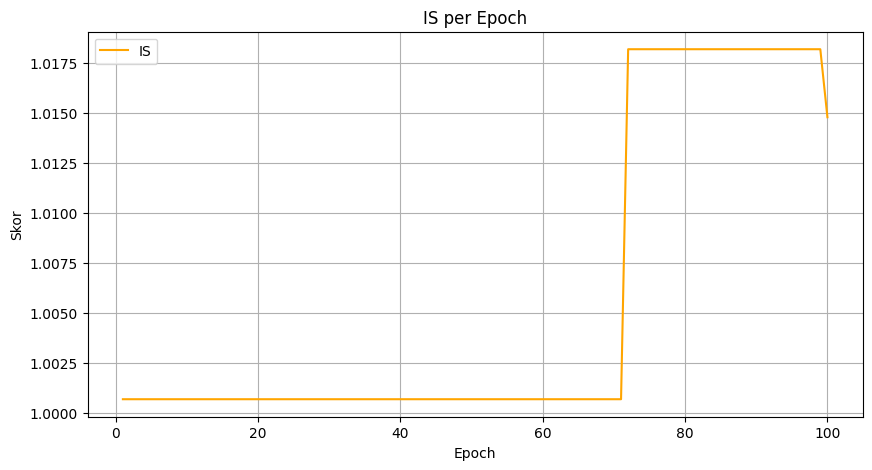

In [8]:
plt.figure(figsize=(10,5))
# plt.plot(df["epoch"], df["FID"], label="FID")
plt.plot(df["epoch"], df["IS"], label="IS", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Skor")
plt.title("IS per Epoch")
plt.legend()
plt.grid(True)
plt.show()

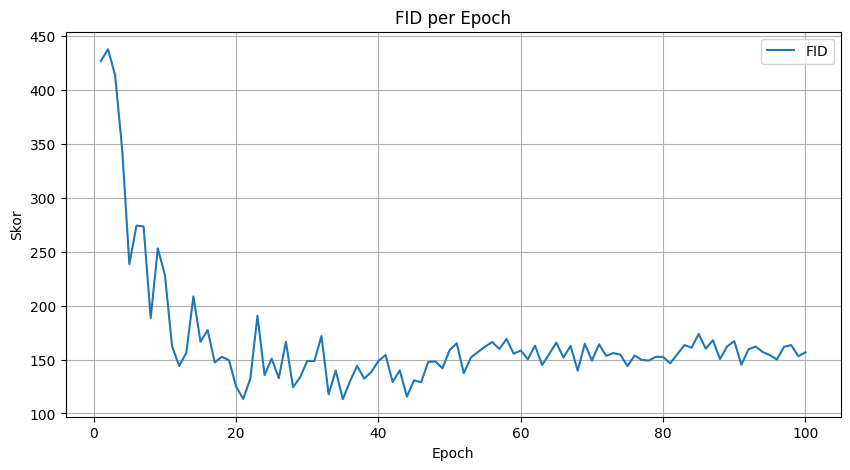

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["FID"], label="FID")
# plt.plot(df["epoch"], df["IS"], label="IS")
plt.xlabel("Epoch")
plt.ylabel("Skor")
plt.title("FID per Epoch")
plt.legend()
plt.grid(True)
plt.show()

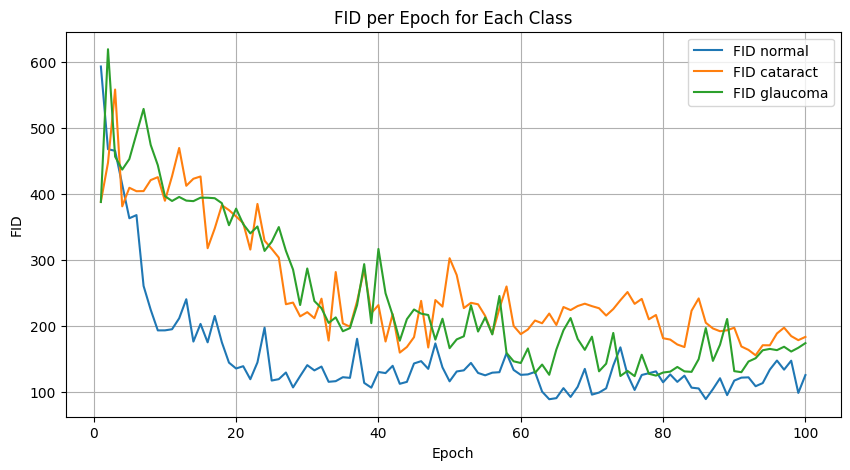

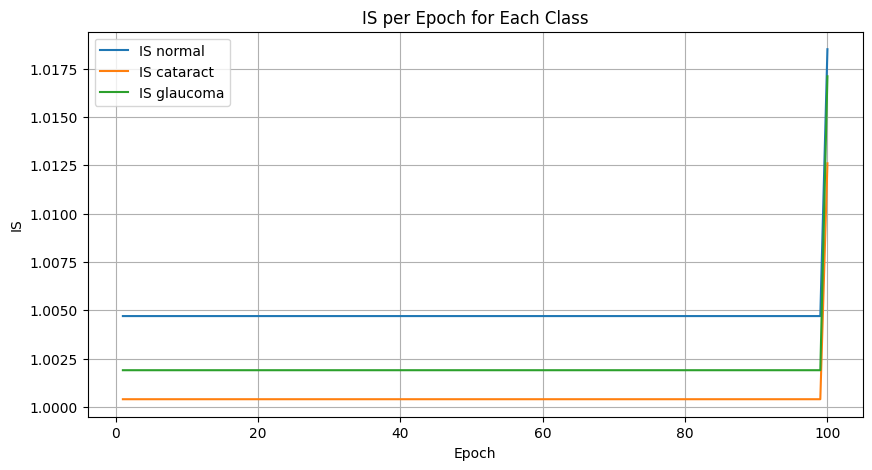

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def extract_metrics(report_path, class_label):
    with open(report_path) as f:
        text = f.read()
    # Extract FID section
    fid_section = re.search(r"--- Per-Epoch FID ---\n(.*?)\n--- Per-Epoch Inception Score ---", text, re.DOTALL)
    fid_lines = fid_section.group(1).strip().split('\n') if fid_section else []
    # Extract IS section
    is_section = re.search(r"--- Per-Epoch Inception Score ---\n(.*)", text, re.DOTALL)
    is_lines = is_section.group(1).strip().split('\n') if is_section else []
    # Parse
    fids = [float(re.search(r": ([0-9.]+)", l).group(1)) for l in fid_lines if ":" in l]
    iss = [float(re.search(r": ([0-9.]+)", l).group(1)) for l in is_lines if ":" in l]
    epochs = list(range(1, min(len(fids), len(iss)) + 1))
    df = pd.DataFrame({"epoch": epochs, "FID": fids[:len(epochs)], "IS": iss[:len(epochs)], "class_label": class_label})
    return df

# Paths to your reports
reports = [
    ("checkpoints/tuned_dcgan_normal/training_report.txt", "dcgan 64x64"),
    ("checkpoints/tuned_dcgan_cataract/training_report.txt", "dcgan 128x128"),
    ("checkpoints/tuned_dcgan_glaucoma/training_report.txt", "dcgan 256x256"),
    ("checkpoints/tuned_acgan-dcgan_normal/training_report.txt", "acgan-dcgan 64x64"),
    ("checkpoints/tuned_acgan-dcgan_cataract/training_report.txt", "acgan-dcgan 128x128"),
    ("checkpoints/tuned_acgan-dcgan_glaucoma/training_report.txt", "acgan-dcgan 256x256"),
]

dfs = [extract_metrics(path, label) for path, label in reports]
df_all = pd.concat(dfs, ignore_index=True)

# Plot FID
plt.figure(figsize=(10,5))
for label in df_all["class_label"].unique():
    plt.plot(df_all[df_all["class_label"] == label]["epoch"],
             df_all[df_all["class_label"] == label]["FID"],
             label=f"FID {label}")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID per Epoch for Each Class")
plt.legend()
plt.grid(True)
plt.show()

# Plot IS
plt.figure(figsize=(10,5))
for label in df_all["class_label"].unique():
    plt.plot(df_all[df_all["class_label"] == label]["epoch"],
             df_all[df_all["class_label"] == label]["IS"],
             label=f"IS {label}")
plt.xlabel("Epoch")
plt.ylabel("IS")
plt.title("IS per Epoch for Each Class")
plt.legend()
plt.grid(True)
plt.show()